In [1]:
import random
import warnings
from datetime import datetime, timedelta
from itertools import combinations
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import shap

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_DIR = Path('data')
ARTIFACTS_DIR = Path('artifacts')
OUTPUT_DIR = Path('output')

In [3]:
def generate_employees(n: int):
    today = datetime.now()
    
    DEPARTMENTS = ['IT', 'Sales', 'Marketing', 'Finance', 'HR', 'Operations', 'Legal']
    LEVELS = ['L1', 'L2', 'L3', 'L4', 'L5', 'L6']
    LEVEL_WEIGHTS = [0.15, 0.25, 0.28, 0.18, 0.10, 0.04]
    LOCATIONS = ['Москва', 'СПб', 'Удаленно', 'Казань', 'Екатеринбург']
    LOC_MULT = {'Москва': 1.15, 'СПб': 1.05, 'Удаленно': 1.00, 'Казань': 0.85, 'Екатеринбург': 0.82}
    EMP_TYPES = ['Полная занятость', 'Частичная', 'Контракт']
    LANGUAGES = ['Python', 'SQL', 'JavaScript', 'Java', 'Go', 'TypeScript', 'C#', 'Rust', 'Scala', 'R']
    TECHNOLOGIES = ['DevOps', 'Cloud', 'ML', 'Data Engineering', 'Security', 'Docker', 'Kubernetes', 'Airflow', 'dbt', 'PostgreSQL', 'React', 'Node.js', 'Spark', 'TensorFlow', 'FastAPI']
    
    records = []
    for i in range(1, n+1):
        eid = f"EMP-{10000+i}"
        dept = random.choices(DEPARTMENTS, weights=[0.28, 0.18, 0.12, 0.15, 0.10, 0.12, 0.05])[0]
        level = np.random.choice(LEVELS, p=LEVEL_WEIGHTS)
        loc = random.choice(LOCATIONS)
        emp_type = random.choices(EMP_TYPES, weights=[0.75, 0.15, 0.10])[0]
        fte = 1.0 if emp_type == 'Полная занятость' else random.choice([0.5, 0.75])
        
        tenure = min(15.0, np.random.exponential(scale=3.5))
        time_in_role = min(tenure, np.random.exponential(scale=2.0))
        time_since_promo = min(tenure, np.random.exponential(scale=1.5))
        
        perf = np.clip(np.random.beta(2.2, 1.4) * 4.2 + 0.8, 1.0, 5.0)
        engagement = np.clip(np.random.normal(3.9, 0.55), 1.0, 5.0)
        
        logit = (-1.5 + 0.5*(1 if tenure < 1.5 else 0) 
                 - 0.25*(perf/5) + 0.2*(time_since_promo/2) 
                 - 0.15*(engagement/5) + np.random.normal(0, 0.25))
        turnover_risk = np.clip(1 / (1 + np.exp(-logit)), 0.05, 0.65)
        
        BASE_SALARY = {'L1': 85000, 'L2': 135000, 'L3': 195000, 'L4': 280000, 'L5': 410000, 'L6': 600000}
        base = BASE_SALARY[level] * LOC_MULT[loc] * fte
        tenure_effect = 1 + 0.12 * min(tenure, 3) + 0.03 * max(0, tenure - 3)
        market_noise = np.random.normal(0, 0.08)
        salary = int(np.clip(base * tenure_effect * (1 + market_noise), 60000, 900000))
        
        n_langs = random.randint(1, 3)
        n_techs = random.randint(2, 4)
        emp_languages = random.sample(LANGUAGES, k=min(n_langs, len(LANGUAGES)))
        emp_technologies = random.sample(TECHNOLOGIES, k=min(n_techs, len(TECHNOLOGIES)))
        
        training_hrs = max(0, int(np.random.poisson(22) + np.random.normal(0, 5)))
        bonus_pct = random.choice([0.0, 0.10, 0.15, 0.20, 0.25])
        
        hire_date = today - timedelta(days=int(tenure * 365))
        last_promo = hire_date + timedelta(days=int(time_since_promo * 365)) if time_since_promo < tenure else hire_date
        manager_id = f"EMP-{10000 + random.randint(1, n)}" if level != 'L1' else None
        
        records.append({
            'employee_id': eid,
            'department': dept,
            'job_level': level,
            'location': loc,
            'employment_type': emp_type,
            'fte_percentage': fte,
            'tenure_years': round(tenure, 1),
            'time_in_current_role_years': round(time_in_role, 1),
            'performance_rating': round(perf, 2),
            'engagement_score': round(engagement, 2),
            'base_salary_monthly': salary,
            'bonus_target_pct': bonus_pct,
            'turnover_risk_score': round(turnover_risk, 3),
            'languages': emp_languages,
            'technologies': emp_technologies,
            'training_hours_ytd': training_hrs,
            'manager_id': manager_id,
            'hire_date': hire_date.strftime('%Y-%m-%d'),
            'last_promotion_date': last_promo.strftime('%Y-%m-%d')
        })
        
    return pd.DataFrame(records)

In [4]:
num_employees = 200
employees_path = DATA_DIR / 'employees.csv'

df_emp = generate_employees(n=num_employees)
print(f"Сгенерировано {len(df_emp)} данных о сотрудниках")

df_emp.to_csv(employees_path, index=False, encoding='utf-8-sig')
print(f"Файл с сотрудниками сохранен в {employees_path}")

Сгенерировано 200 данных о сотрудниках
Файл с сотрудниками сохранен в data\employees.csv


In [5]:
df_emp.head()

,employee_id,department,job_level,location,employment_type,fte_percentage,tenure_years,time_in_current_role_years,performance_rating,engagement_score,base_salary_monthly,bonus_target_pct,turnover_risk_score,languages,technologies,training_hours_ytd,manager_id,hire_date,last_promotion_date
0,EMP-10001,Finance,L2,Москва,Полная занятость,1.00,10.5,2.6,3.53,4.77,236988,0.25,0.184,[JavaScript],"[Node.js, Cloud]",19,EMP-10023,2015-10-16,2017-02-26
1,EMP-10002,Finance,L2,Москва,Полная занятость,1.00,2.6,1.1,2.31,4.71,204858,0.25,0.147,[Scala],"[PostgreSQL, DevOps]",15,EMP-10051,2023-09-19,2024-03-25
2,EMP-10003,Finance,L3,Екатеринбург,Полная занятость,1.00,0.7,0.1,3.30,3.89,183804,0.20,0.185,"[Go, Python]","[Spark, FastAPI, ML, Node.js]",12,EMP-10088,2025-08-31,2025-08-31
3,EMP-10004,IT,L3,СПб,Контракт,0.75,0.7,0.7,3.78,3.84,147021,0.15,0.213,[C#],"[Cloud, Docker]",23,EMP-10155,2025-08-08,2025-08-08
4,EMP-10005,IT,L2,Москва,Полная занятость,1.00,2.7,0.3,2.36,4.47,192418,0.25,0.218,"[C#, SQL, Go]","[TensorFlow, React]",26,EMP-10093,2023-08-01,2026-01-04


In [6]:
PROJECT_CONFIG = {
    'name': 'AI Dashboard',
    'req_languages': ['Python', 'SQL', 'Go'],
    'req_technologies': ['DevOps', 'Cloud', 'ML', 'Data Engineering'],
    'timeline_days': 90,
    'budget_limit': 4_500_000,
    'min_team_size': 3,
    'max_team_size': 5
}

In [7]:
FEATURE_COLS = [
    'team_size', 'skill_coverage', 'avg_performance', 'avg_engagement', 'avg_turnover_risk', 'senior_ratio', 'budget_fit', 'timeline_days', 'budget_limit'
]

In [8]:
def generate_training_data(df_emp: pd.DataFrame, n_projects: int, seed: int = 42) -> pd.DataFrame:
    np.random.seed(seed)
    random.seed(seed)
    
    PROJECT_PROFILES = [
        {'timeline_days': 90,  'budget_limit': 4_500_000, 'req_skills': {'Python', 'SQL', 'Go', 'DevOps', 'Cloud', 'ML', 'Data Engineering'}},
        {'timeline_days': 60,  'budget_limit': 3_000_000, 'req_skills': {'Python', 'SQL', 'JavaScript', 'Analytics', 'Automation'}},
        {'timeline_days': 120, 'budget_limit': 6_000_000, 'req_skills': {'Go', 'Java', 'Cloud', 'DevOps', 'Kubernetes'}},
        {'timeline_days': 45,  'budget_limit': 2_500_000, 'req_skills': {'R', 'Python', 'SQL', 'ML', 'BI Dashboards'}},
        {'timeline_days': 100, 'budget_limit': 5_000_000, 'req_skills': {'Java', 'SQL', 'C#', 'Security', 'Data Engineering'}}
    ]
    
    records = []
    emp_ids = df_emp['employee_id'].tolist()
    
    for i in range(n_projects):
        profile = random.choice(PROJECT_PROFILES)
        team_size = random.randint(3, 5)
        team = df_emp[df_emp['employee_id'].isin(random.sample(emp_ids, k=team_size))]
        
        lang_set = set().union(*[set(l) if isinstance(l, (list, tuple)) else set() for l in team['languages']])
        tech_set = set().union(*[set(t) if isinstance(t, (list, tuple)) else set() for t in team['technologies']])
        team_skills = lang_set.union(tech_set)
        
        skill_coverage = len(profile['req_skills'].intersection(team_skills)) / len(profile['req_skills']) if profile['req_skills'] else 0.0
        estimated_cost = team['base_salary_monthly'].sum() * (profile['timeline_days'] / 30.0)
        budget_fit = 1.0 if estimated_cost <= profile['budget_limit'] else 0.65
        
        success_score = (
            0.30 * skill_coverage +
            0.25 * (team['performance_rating'].mean() / 5.0) +
            0.15 * (team['engagement_score'].mean() / 5.0) +
            0.15 * (1.0 - team['turnover_risk_score'].mean()) +
            0.10 * (team['job_level'].isin(['L4','L5','L6'])).mean() +
            0.05 * budget_fit +
            0.05 * (profile['timeline_days'] / 120.0) +
            np.random.normal(0, 0.04)
        )
        
        records.append({
            'team_size': team_size,
            'skill_coverage': round(skill_coverage, 3),
            'avg_performance': round(team['performance_rating'].mean(), 3),
            'avg_engagement': round(team['engagement_score'].mean(), 3),
            'avg_turnover_risk': round(team['turnover_risk_score'].mean(), 3),
            'senior_ratio': round((team['job_level'].isin(['L4','L5','L6'])).mean(), 3),
            'budget_fit': budget_fit,
            'timeline_days': profile['timeline_days'],
            'budget_limit': profile['budget_limit'],
            'project_success': np.clip(success_score, 0.35, 0.95)
        })
        
    return pd.DataFrame(records)

In [9]:
num_training_data = 800

df_train = generate_training_data(df_emp, n_projects=num_training_data)
print(f"Сгенерировано {len(df_train)} проектов для обучения")

Сгенерировано 800 проектов для обучения


In [10]:
df_train.head()

,team_size,skill_coverage,avg_performance,avg_engagement,avg_turnover_risk,senior_ratio,budget_fit,timeline_days,budget_limit,project_success
0,3,0.571,3.783,4.123,0.211,0.333,1.0,90,4500000,0.743397
1,3,0.000,3.557,3.617,0.154,0.333,1.0,60,3000000,0.516036
2,3,0.400,2.887,4.107,0.176,0.667,1.0,100,5000000,0.695424
3,3,0.429,3.800,3.687,0.198,0.000,1.0,90,4500000,0.697843
4,3,0.800,3.377,3.640,0.166,0.333,1.0,100,5000000,0.758717


In [11]:
def train_and_evaluate_model(df_train: pd.DataFrame, test_size: float = 0.2):
    X = df_train[FEATURE_COLS]
    y = df_train['project_success']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=RANDOM_STATE)
    
    model = RandomForestRegressor(n_estimators=150, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    metrics = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }
    print(f"Метрики на тестовой выборке:\nMAE: {metrics['MAE']:.4f}\nR^2 : {metrics['R2']:.4f}")
    return model, X_train, X_test, y_train, y_test, metrics

In [12]:
model, X_train, X_test, y_train, y_test, metrics = train_and_evaluate_model(df_train)

Метрики на тестовой выборке:
MAE: 0.0366
R^2 : 0.7297


In [13]:
def generate_candidates_and_predict(model, df_emp: pd.DataFrame, config: dict, n_samples: int = 12000, seed: int = 42) -> pd.DataFrame:
    np.random.seed(seed)
    req_skills = set(config['req_languages'] + config['req_technologies'])
    timeline = config['timeline_days']
    budget = config['budget_limit']
    
    candidates = []
    for _ in range(n_samples):
        size = np.random.randint(config['min_team_size'], config['max_team_size'] + 1)
        idx = np.random.choice(len(df_emp), size=size, replace=False)
        team = df_emp.iloc[idx]
        
        cost = team['base_salary_monthly'].sum() * (timeline / 30.0)
        if cost > budget: continue
        
        lang_set = set().union(*[set(l) for l in team['languages'] if isinstance(l, (list, tuple))])
        tech_set = set().union(*[set(t) for t in team['technologies'] if isinstance(t, (list, tuple))])
        cov = len(req_skills.intersection(lang_set | tech_set)) / len(req_skills)
        if cov < 0.3: continue
        
        candidates.append({
            'team_size': size,
            'skill_coverage': cov,
            'avg_performance': team['performance_rating'].mean(),
            'avg_engagement': team['engagement_score'].mean(),
            'avg_turnover_risk': team['turnover_risk_score'].mean(),
            'senior_ratio': (team['job_level'].isin(['L4','L5','L6'])).mean(),
            'budget_fit': 1.0,
            'timeline_days': timeline,
            'budget_limit': budget,
            'team_ids': ', '.join(team['employee_id'])
        })
        
    X_cand = pd.DataFrame(candidates)
    if X_cand.empty:
        return pd.DataFrame(columns=FEATURE_COLS + ['team_ids', 'predicted_success', 'ci_low', 'ci_high'])
        
    X_feat = X_cand[FEATURE_COLS].reindex(columns=FEATURE_COLS, fill_value=0.0)
    
    preds = model.predict(X_feat)
    
    n_boot = 40
    boot_preds = np.array([
        model.predict(X_feat + np.random.normal(0, 0.015, X_feat.shape)) for _ in range(n_boot)
    ])
    ci_low = np.percentile(boot_preds, 2.5, axis=0)
    ci_high = np.percentile(boot_preds, 97.5, axis=0)
    
    X_cand['predicted_success'] = preds
    X_cand['ci_low'] = ci_low
    X_cand['ci_high'] = ci_high
    return X_cand

In [14]:
df_candidates = generate_candidates_and_predict(model, df_emp, PROJECT_CONFIG, n_samples=12000)
print(f"Прошло фильтров: {len(df_candidates)} из 12 000 команд")

Прошло фильтров: 9587 из 12 000 команд


In [15]:
def analyze_top_teams(model, df_candidates: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    top_teams = df_candidates.nlargest(top_n, 'predicted_success').copy()
    top_teams.reset_index(drop=True, inplace=True)
    top_teams['rank'] = top_teams.index + 1
    
    X_top = top_teams[FEATURE_COLS]
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_top)
    
    drivers_list = []
    for i in range(len(top_teams)):
        top_idx = np.argsort(np.abs(shap_vals[i]))[::-1][:2]
        drv = []
        for j in top_idx:
            sign = "+" if shap_vals[i, j] > 0 else ""
            drv.append(f"{FEATURE_COLS[j]} ({sign}{shap_vals[i, j]*100:.0f}%)")
        drivers_list.append(" | ".join(drv))
    top_teams['key_drivers'] = drivers_list
    
    cf_rules = []
    for _, row in top_teams.iterrows():
        if row['predicted_success'] >= 0.85:
            cf_rules.append("Оптимальный баланс. Масштабировать без изменений.")
        elif row['skill_coverage'] < 0.75:
            cf_rules.append("Добавить Fullstack/DevOps → покрытие стека ↑")
        elif row['avg_turnover_risk'] > 0.25:
            cf_rules.append("Заменить участника с высоким риском ухода → стабильность ↑")
        elif row['senior_ratio'] < 0.25:
            cf_rules.append("Включить L4+ специалиста → архитектурные риски ↓")
        else:
            cf_rules.append("Рассмотреть замену для повышения среднего Performance → успех ↑")
    top_teams['counterfactual'] = cf_rules
    return top_teams

In [16]:
df_top = analyze_top_teams(model, df_candidates, top_n=10)

In [17]:
def visualize_and_export(df_candidates: pd.DataFrame, df_top: pd.DataFrame, output_path: str = 'decision_package.csv'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(df_candidates['predicted_success'], bins=30, kde=True, ax=axes[0], color='#2196F3')
    axes[0].set_title('Распределение прогнозируемого успеха команд (Монте-Карло)', fontsize=13)
    axes[0].set_xlabel('Predicted Success')
    axes[0].axvline(df_candidates['predicted_success'].mean(), color='r', linestyle='--', label=f'μ={df_candidates["predicted_success"].mean():.3f}')
    axes[0].legend()
    
    model = RandomForestRegressor()
    if 'shap_values' in locals():
        shap.summary_plot(shap_values, X_top, plot_type="bar", show=False, ax=axes[1])
    else:
        sns.barplot(x=FEATURE_COLS, y=df_top[FEATURE_COLS].std(), ax=axes[1], palette="viridis")
        axes[1].set_title('Дисперсия признаков (альтернатива при отсутствии SHAP объекта)', fontsize=12)
        axes[1].tick_params(axis='x', rotation=45)
        
    plt.tight_layout()
    plt.show()
    
    cols_final = ['rank', 'team_ids', 'predicted_success', 'ci_low', 'ci_high', 'key_drivers', 'counterfactual']
    report = df_top[cols_final].copy()
    report['predicted_success'] = (report['predicted_success'] * 100).round(1).astype(str) + '%'
    report['95%_ДИ'] = "[" + (report['ci_low']*100).round(0).astype(int).astype(str) + "%; " + (report['ci_high']*100).round(0).astype(int).astype(str) + "%]"
    report.drop(columns=['ci_low', 'ci_high'], inplace=True)
    output_path = OUTPUT_DIR / output_path
    report.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"Отчет сохранен: {output_path}")
    return report

C:\Users\onikiri\AppData\Local\Temp\ipykernel_5528\565095342.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_top, df_top[FEATURE_COLS], plot_type="bar", show=False)


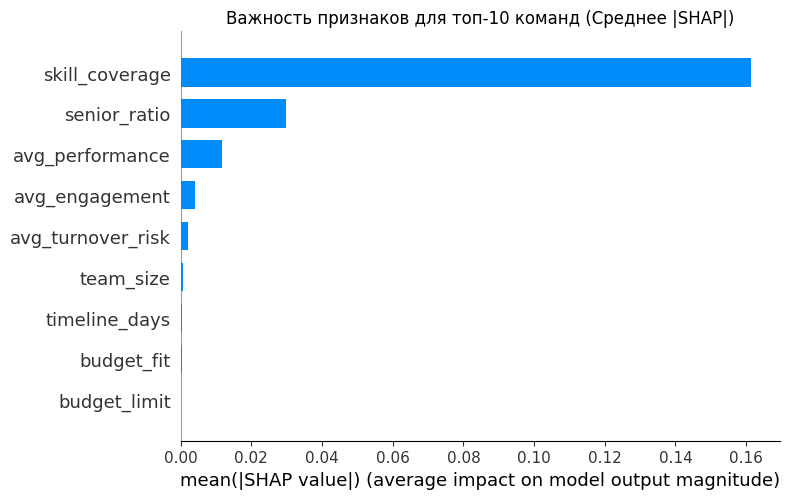

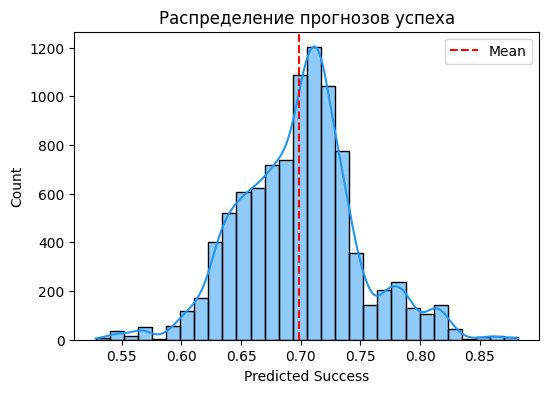

C:\Users\onikiri\AppData\Local\Temp\ipykernel_5528\7918140.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=FEATURE_COLS, y=df_top[FEATURE_COLS].std(), ax=axes[1], palette="viridis")


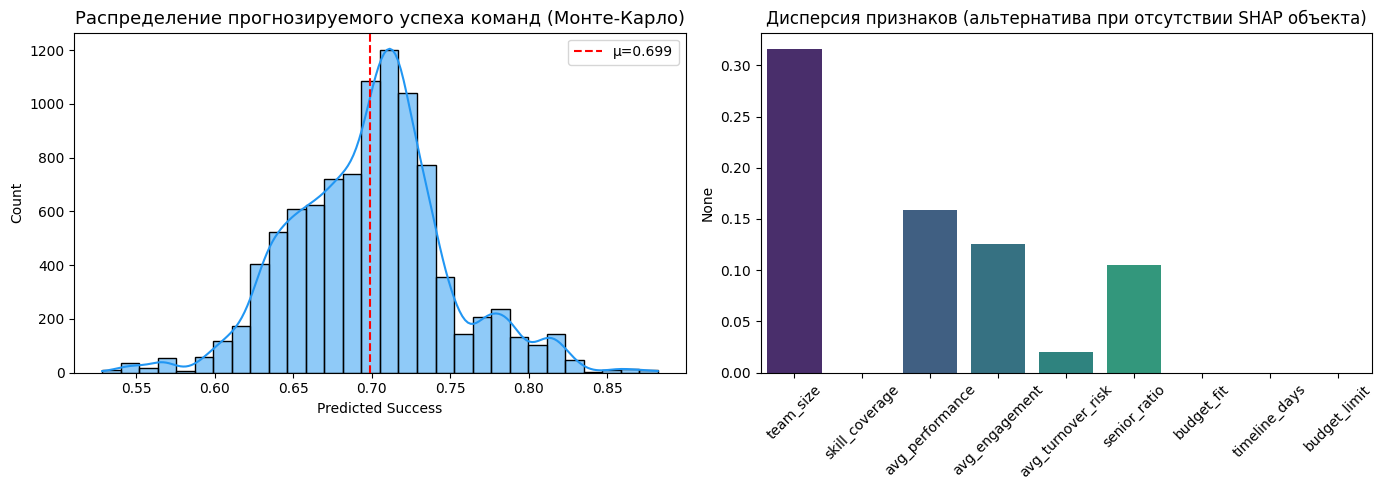

Отчет сохранен: output\decision_package.csv


,rank,team_ids,predicted_success,key_drivers,counterfactual,95%_ДИ
0,1,"EMP-10128, EMP-10025, EMP-10148, EMP-10076",88.2%,skill_coverage (+17%) | senior_ratio (+3%),Оптимальный баланс. Масштабировать без изменений.,[87%; 88%]
1,2,"EMP-10028, EMP-10115, EMP-10100, EMP-10053, EM...",88.2%,skill_coverage (+16%) | senior_ratio (+3%),Оптимальный баланс. Масштабировать без изменений.,[87%; 88%]
2,3,"EMP-10039, EMP-10075, EMP-10138, EMP-10110",87.9%,skill_coverage (+16%) | senior_ratio (+3%),Оптимальный баланс. Масштабировать без изменений.,[88%; 89%]
3,4,"EMP-10115, EMP-10079, EMP-10198, EMP-10058",87.9%,skill_coverage (+16%) | senior_ratio (+3%),Оптимальный баланс. Масштабировать без изменений.,[88%; 88%]
4,5,"EMP-10148, EMP-10025, EMP-10126, EMP-10071",87.8%,skill_coverage (+16%) | senior_ratio (+3%),Оптимальный баланс. Масштабировать без изменений.,[87%; 89%]
5,6,"EMP-10184, EMP-10166, EMP-10075, EMP-10182",87.7%,skill_coverage (+16%) | senior_ratio (+3%),Оптимальный баланс. Масштабировать без изменений.,[87%; 88%]
6,7,"EMP-10147, EMP-10003, EMP-10020, EMP-10133",87.6%,skill_coverage (+16%) | senior_ratio (+3%),Оптимальный баланс. Масштабировать без изменений.,[87%; 88%]
7,8,"EMP-10167, EMP-10047, EMP-10064, EMP-10157",87.5%,skill_coverage (+15%) | senior_ratio (+3%),Оптимальный баланс. Масштабировать без изменений.,[87%; 88%]
8,9,"EMP-10175, EMP-10025, EMP-10115, EMP-10037",87.3%,skill_coverage (+16%) | senior_ratio (+3%),Оптимальный баланс. Масштабировать без изменений.,[87%; 88%]
9,10,"EMP-10025, EMP-10044, EMP-10115, EMP-10135",87.2%,skill_coverage (+16%) | senior_ratio (+3%),Оптимальный баланс. Масштабировать без изменений.,[87%; 88%]


In [20]:
explainer = shap.TreeExplainer(model)
shap_vals_top = explainer.shap_values(df_top[FEATURE_COLS])

plt.figure(figsize=(6,4))
shap.summary_plot(shap_vals_top, df_top[FEATURE_COLS], plot_type="bar", show=False)
plt.title("Важность признаков для топ-10 команд (Среднее |SHAP|)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df_candidates['predicted_success'], bins=30, kde=True, color='#2196F3')
plt.axvline(df_candidates['predicted_success'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Распределение прогнозов успеха')
plt.xlabel('Predicted Success')
plt.legend()
plt.savefig(ARTIFACTS_DIR / "training_curves.png")
plt.show()

final_report = visualize_and_export(df_candidates, df_top)
display(final_report.head(10))